In [7]:
from huggingface_hub import notebook_login
notebook_login()

model.push_to_hub("your-hf-username/mistral-7b-medical-finetuned")
tokenizer.push_to_hub("your-hf-username/mistral-7b-medical-finetuned")

HfHubHTTPError: Client error '401 Unauthorized' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-6a2d84cc-7eaf09872457d054439e361a;0a37dc82-9583-4281-8855-bf57352a4947)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401

Invalid username or password.

Token has not been saved to git credential helper.


In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_path = "/teamspace/studios/this_studio/mistral-medical-finetuned"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    dtype=torch.float16,
    device_map={"": "cuda:0"}
)
model.eval()

def ask(question):
    inputs = tokenizer(question, return_tensors="pt")
    inputs = {k: v.to("cuda:0") for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"Q: {question}")
    print(f"A: {response}")
    print("-" * 50)

ask("What are the symptoms of diabetes?")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/128 [00:00<?, ?it/s]

Q: What are the symptoms of diabetes?
A: What are the symptoms of diabetes?

The symptoms of diabetes are:

- Increased thirst
- Increased urination
- Increased hunger
- Weight loss
- Fatigue
- Blurred vision
- Slow healing of cuts and wounds
- Numbness or tingling in the hands or feet
- Recurring infections

What is the difference between type 1 and type 2 diabetes?

Type 1 diabetes is an autoimmune disease in which the body’s immune system attacks and destroys the insulin-producing beta cells in the pancreas. This results in a lack of insulin production and the inability to regulate blood sugar levels. Type 1 diabetes is usually
--------------------------------------------------


In [2]:
!pip install gradio -q

In [10]:
from huggingface_hub import login, create_repo

# Login
# token removed for security

# Create repo
create_repo("neelam-builds/mistral-7b-medical-finetuned", private=False)

# Push model
model.push_to_hub("neelam-builds/mistral-7b-medical-finetuned")
tokenizer.push_to_hub("neelam-builds/mistral-7b-medical-finetuned")

HfHubHTTPError: (Request ID: Root=1-6a2d8894-01c5af7b6648f2221b43edc6;469e07e5-0356-4471-980c-e2ee04999cd2)

403 Forbidden: You don't have the rights to create a model under the namespace "neelam-builds".
Cannot access content at: https://huggingface.co/api/repos/create.
Make sure your token has the correct permissions.

In [11]:
from huggingface_hub import login, create_repo

# token removed for security

create_repo("neelam-builds/mistral-7b-medical-finetuned", private=False, exist_ok=True)

model.push_to_hub("neelam-builds/mistral-7b-medical-finetuned")
tokenizer.push_to_hub("neelam-builds/mistral-7b-medical-finetuned")

Token has not been saved to git credential helper.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/neelam-builds/mistral-7b-medical-finetuned/commit/6bad5b59d9aaea5bd8a74646744126b92ccaa612', commit_message='Upload tokenizer', commit_description='', oid='6bad5b59d9aaea5bd8a74646744126b92ccaa612', pr_url=None, repo_url=RepoUrl('https://huggingface.co/neelam-builds/mistral-7b-medical-finetuned', endpoint='https://huggingface.co', repo_type='model', repo_id='neelam-builds/mistral-7b-medical-finetuned'), pr_revision=None, pr_num=None)

In [12]:
import subprocess
subprocess.run(["git", "config", "--global", "credential.helper", "store"])

CompletedProcess(args=['git', 'config', '--global', 'credential.helper', 'store'], returncode=0)

In [13]:
create_repo("neelam-builds/mistral-7b-medical-finetuned", private=False, exist_ok=True)

model.push_to_hub("neelam-builds/mistral-7b-medical-finetuned")
tokenizer.push_to_hub("neelam-builds/mistral-7b-medical-finetuned")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/neelam-builds/mistral-7b-medical-finetuned/commit/6bad5b59d9aaea5bd8a74646744126b92ccaa612', commit_message='Upload tokenizer', commit_description='', oid='6bad5b59d9aaea5bd8a74646744126b92ccaa612', pr_url=None, repo_url=RepoUrl('https://huggingface.co/neelam-builds/mistral-7b-medical-finetuned', endpoint='https://huggingface.co', repo_type='model', repo_id='neelam-builds/mistral-7b-medical-finetuned'), pr_revision=None, pr_num=None)

In [14]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# Load the fine-tuned model
model_path = "/teamspace/studios/this_studio/mistral-medical-finetuned"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.float16,
    device_map="auto"
)

def ask(question):
    inputs = tokenizer(question, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=True,
        temperature=0.7,
        pad_token_id=tokenizer.eos_token_id
    )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"Q: {question}")
    print(f"A: {response}")
    print("-" * 50)

# Test with these questions
ask("What are the symptoms of diabetes?")
ask("What is hypertension?")
ask("What causes fever?")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Loading weights:   0%|          | 0/128 [00:00<?, ?it/s]

RuntimeError: Expected all tensors to be on the same device, but got mat2 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_mm)

In [9]:
import gradio as gr
print(gr.__version__)

6.18.0


In [10]:
import gradio as gr
import torch

def medical_assistant(question, history):
    if not question.strip():
        return "", history
    
    inputs = tokenizer(question, return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=300,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if question in response:
        response = response.replace(question, "").strip()
    
    history = history or []
    history.append({"role": "user", "content": question})
    history.append({"role": "assistant", "content": response})
    return "", history

with gr.Blocks() as demo:

    gr.HTML("""
    <div style="text-align:center; padding:30px 0 15px 0;">
        <h1 style="font-size:2.5em; background:linear-gradient(90deg,#00d2ff,#7b2ff7);
        -webkit-background-clip:text; -webkit-text-fill-color:transparent;
        font-weight:800; margin-bottom:8px;">🏥 MediAsk</h1>
        <p style="color:#9999bb; font-size:0.95em;">
        Your personal medical knowledge assistant — ask anything, get clear answers</p>
    </div>
    """)

    chatbot = gr.Chatbot(
        label="",
        height=460,
        show_label=False,
        render_markdown=True,
    )

    with gr.Row():
        msg = gr.Textbox(
            placeholder="Type your medical question here...",
            show_label=False,
            scale=9,
            container=False,
        )
        send = gr.Button("Send ➤", scale=1)

    gr.HTML("<p style='color:#777799; font-size:0.82em; text-align:center; margin:12px 0 6px 0'>💡 Try one of these:</p>")

    with gr.Row():
        q1 = gr.Button("🩺 Symptoms of diabetes?")
        q2 = gr.Button("❤️ What is hypertension?")
        q3 = gr.Button("🤒 What causes fever?")
        q4 = gr.Button("💊 Uses of paracetamol?")

    clear = gr.Button("🗑️ Clear Chat")

    gr.HTML("""
    <div style="text-align:center; color:#555577; font-size:0.78em; padding:20px;">
        ⚠️ MediAsk is for informational purposes only.<br>
        Always consult a qualified doctor for medical advice.
    </div>
    """)

    history = gr.State([])

    send.click(medical_assistant, [msg, history], [msg, chatbot])
    msg.submit(medical_assistant, [msg, history], [msg, chatbot])
    q1.click(lambda h: medical_assistant("What are the symptoms of diabetes?", h), [history], [msg, chatbot])
    q2.click(lambda h: medical_assistant("What is hypertension?", h), [history], [msg, chatbot])
    q3.click(lambda h: medical_assistant("What causes fever?", h), [history], [msg, chatbot])
    q4.click(lambda h: medical_assistant("What is paracetamol used for?", h), [history], [msg, chatbot])
    clear.click(lambda: ([], []), None, [chatbot, history])

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://4f549f21844e543fe7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [11]:
from huggingface_hub import HfApi, login

# token removed for security

api = HfApi()
api.create_repo(
    repo_id="neelam-builds/mediask",
    repo_type="space",
    space_sdk="gradio",
    private=False,
    exist_ok=True
)
print("Space created!")

HfHubHTTPError: Invalid user token.

In [12]:
from huggingface_hub import HfApi, login

# token removed for security
print("Logged in!")

Logged in!


In [13]:
api = HfApi()
api.create_repo(
    repo_id="neelam-builds/mediask",
    repo_type="space",
    space_sdk="gradio",
    private=False,
    exist_ok=True
)
print("Space created!")

Space created!


In [14]:
app_code = '''
import gradio as gr
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load model from HF Hub
model_name = "neelam-builds/mistral-7b-medical-finetuned"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="auto",
    load_in_4bit=True
)
model.eval()

def medical_assistant(question, history):
    if not question.strip():
        return "", history
    
    inputs = tokenizer(question, return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=300,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if question in response:
        response = response.replace(question, "").strip()
    
    history = history or []
    history.append({"role": "user", "content": question})
    history.append({"role": "assistant", "content": response})
    return "", history

with gr.Blocks() as demo:
    gr.HTML("""
    <div style="text-align:center; padding:30px 0 15px 0;">
        <h1 style="font-size:2.5em; background:linear-gradient(90deg,#00d2ff,#7b2ff7);
        -webkit-background-clip:text; -webkit-text-fill-color:transparent;
        font-weight:800; margin-bottom:8px;">🏥 MediAsk</h1>
        <p style="color:#9999bb; font-size:0.95em;">
        Your personal medical knowledge assistant — ask anything, get clear answers</p>
    </div>
    """)

    chatbot = gr.Chatbot(label="", height=460, show_label=False, render_markdown=True)

    with gr.Row():
        msg = gr.Textbox(placeholder="Type your medical question here...",
                        show_label=False, scale=9, container=False)
        send = gr.Button("Send ➤", scale=1)

    gr.HTML("<p style=\'color:#777799; font-size:0.82em; text-align:center; margin:12px 0 6px 0\'>💡 Try one of these:</p>")

    with gr.Row():
        q1 = gr.Button("🩺 Symptoms of diabetes?")
        q2 = gr.Button("❤️ What is hypertension?")
        q3 = gr.Button("🤒 What causes fever?")
        q4 = gr.Button("💊 Uses of paracetamol?")

    clear = gr.Button("🗑️ Clear Chat")

    gr.HTML("""
    <div style="text-align:center; color:#555577; font-size:0.78em; padding:20px;">
        ⚠️ MediAsk is for informational purposes only.<br>
        Always consult a qualified doctor for medical advice.
    </div>
    """)

    history = gr.State([])

    send.click(medical_assistant, [msg, history], [msg, chatbot])
    msg.submit(medical_assistant, [msg, history], [msg, chatbot])
    q1.click(lambda h: medical_assistant("What are the symptoms of diabetes?", h), [history], [msg, chatbot])
    q2.click(lambda h: medical_assistant("What is hypertension?", h), [history], [msg, chatbot])
    q3.click(lambda h: medical_assistant("What causes fever?", h), [history], [msg, chatbot])
    q4.click(lambda h: medical_assistant("What is paracetamol used for?", h), [history], [msg, chatbot])
    clear.click(lambda: ([], []), None, [chatbot, history])

demo.launch()
'''

with open("/teamspace/studios/this_studio/app.py", "w") as f:
    f.write(app_code)
print("app.py created!")

app.py created!


In [15]:
api.upload_file(
    path_or_fileobj="/teamspace/studios/this_studio/app.py",
    path_in_repo="app.py",
    repo_id="neelam-builds/mediask",
    repo_type="space"
)
print("Uploaded!")

Uploaded!


In [16]:
requirements = """torch
transformers
gradio
peft
bitsandbytes
accelerate
huggingface_hub
"""

with open("/teamspace/studios/this_studio/requirements.txt", "w") as f:
    f.write(requirements)
print("requirements.txt created!")

requirements.txt created!


In [17]:
api.upload_file(
    path_or_fileobj="/teamspace/studios/this_studio/requirements.txt",
    path_in_repo="requirements.txt",
    repo_id="neelam-builds/mediask",
    repo_type="space"
)
print("Uploaded!")

Uploaded!


In [18]:
app_code = '''
import gradio as gr
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Load model from HF Hub
model_name = "neelam-builds/mistral-7b-medical-finetuned"

bnb_config = BitsAndBytesConfig(load_in_4bit=True)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
)
model.eval()

def medical_assistant(question, history):
    if not question.strip():
        return "", history
    
    inputs = tokenizer(question, return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=300,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if question in response:
        response = response.replace(question, "").strip()
    
    history = history or []
    history.append({"role": "user", "content": question})
    history.append({"role": "assistant", "content": response})
    return "", history

with gr.Blocks() as demo:
    gr.HTML("""
    <div style="text-align:center; padding:30px 0 15px 0;">
        <h1 style="font-size:2.5em; background:linear-gradient(90deg,#00d2ff,#7b2ff7);
        -webkit-background-clip:text; -webkit-text-fill-color:transparent;
        font-weight:800; margin-bottom:8px;">🏥 MediAsk</h1>
        <p style="color:#9999bb; font-size:0.95em;">
        Your personal medical knowledge assistant — ask anything, get clear answers</p>
    </div>
    """)

    chatbot = gr.Chatbot(label="", height=460, show_label=False, render_markdown=True)

    with gr.Row():
        msg = gr.Textbox(placeholder="Type your medical question here...",
                        show_label=False, scale=9, container=False)
        send = gr.Button("Send ➤", scale=1)

    gr.HTML("<p style=\'color:#777799; font-size:0.82em; text-align:center; margin:12px 0 6px 0\'>💡 Try one of these:</p>")

    with gr.Row():
        q1 = gr.Button("🩺 Symptoms of diabetes?")
        q2 = gr.Button("❤️ What is hypertension?")
        q3 = gr.Button("🤒 What causes fever?")
        q4 = gr.Button("💊 Uses of paracetamol?")

    clear = gr.Button("🗑️ Clear Chat")

    gr.HTML("""
    <div style="text-align:center; color:#555577; font-size:0.78em; padding:20px;">
        ⚠️ MediAsk is for informational purposes only.<br>
        Always consult a qualified doctor for medical advice.
    </div>
    """)

    history = gr.State([])

    send.click(medical_assistant, [msg, history], [msg, chatbot])
    msg.submit(medical_assistant, [msg, history], [msg, chatbot])
    q1.click(lambda h: medical_assistant("What are the symptoms of diabetes?", h), [history], [msg, chatbot])
    q2.click(lambda h: medical_assistant("What is hypertension?", h), [history], [msg, chatbot])
    q3.click(lambda h: medical_assistant("What causes fever?", h), [history], [msg, chatbot])
    q4.click(lambda h: medical_assistant("What is paracetamol used for?", h), [history], [msg, chatbot])
    clear.click(lambda: ([], []), None, [chatbot, history])

demo.launch()
'''

with open("/teamspace/studios/this_studio/app.py", "w") as f:
    f.write(app_code)
print("app.py updated!")

app.py updated!


In [19]:
api.upload_file(
    path_or_fileobj="/teamspace/studios/this_studio/app.py",
    path_in_repo="app.py",
    repo_id="neelam-builds/mediask",
    repo_type="space"
)
print("Uploaded!")

Uploaded!


In [20]:
import subprocess

# Configure git
subprocess.run(["git", "config", "--global", "user.email", "your-email@gmail.com"])
subprocess.run(["git", "config", "--global", "user.name", "Neelamyadav14"])

# Clone your repo
subprocess.run(["git", "clone", "https://github.com/Neelamyadav14/mistral-medical-finetune.git", 
                "/teamspace/studios/this_studio/mistral-medical-finetune"])
print("Cloned!")

Cloning into '/teamspace/studios/this_studio/mistral-medical-finetune'...

Cloned!


In [21]:
import os
files = os.listdir("/teamspace/studios/this_studio/")
print(files)

['app.py', 'loss_curve.png', '.config', '.zshrc', '.condarc', '.gitconfig', '.sudo_as_admin_successful', '.zcompdump', '.nvm', '.oh-my-zsh', 'train.ipynb', '.ipython', '.lightningignore', '.lightning_studio', '.cache', '.bashrc', '.vscode', '.docker', '.nv', '.vimrc', 'mistral-medical-finetune', '.hushlogin', '.windsurf-server', 'medical-mistral', 'main.py', 'requirements.txt', '.profile', '.idea', 'mistral-medical-finetuned', '.vscode-server', '.gradio', '.jupyter', '.ssh', '.local', '.cursor-server', '.zsh_history']


In [15]:
model.save_pretrained("/teamspace/studios/this_studio/mistral-medical-finetuned")
tokenizer.save_pretrained("/teamspace/studios/this_studio/mistral-medical-finetuned")
print("Saved!")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/modeling_utils.py:3486: UserWarning: Attempting to save a model with offloaded modules. Ensure that unallocated cpu memory exceeds the `shard_size` (50GB default)
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved!


In [8]:
from huggingface_hub import login

# token removed for security


In [9]:
model.push_to_hub("your-username/mistral-7b-medical-finetuned")
tokenizer.push_to_hub("your-username/mistral-7b-medical-finetuned")

HfHubHTTPError: (Request ID: Root=1-6a2d87e0-266141722cb0967a7630637b;f2ef6252-68e0-4c64-86eb-da1ccdf9484e)

403 Forbidden: You don't have the rights to create a model under the namespace "your-username".
Cannot access content at: https://huggingface.co/api/repos/create.
Make sure your token has the correct permissions.

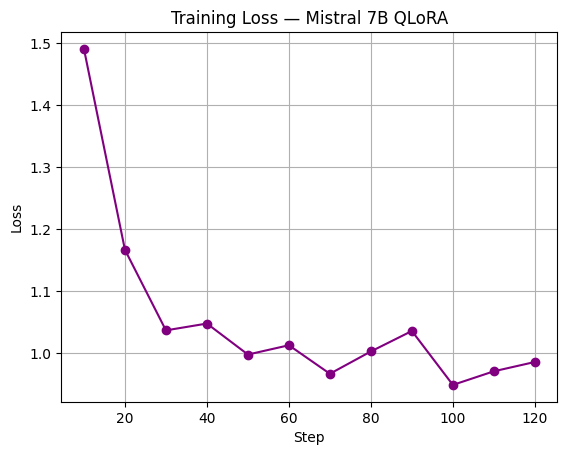

In [6]:
import matplotlib.pyplot as plt

steps = [10,20,30,40,50,60,70,80,90,100,110,120]
loss  = [1.491,1.167,1.037,1.048,0.998,1.013,0.967,1.003,1.036,0.949,0.971,0.986]

plt.plot(steps, loss, marker='o', color='purple')
plt.title("Training Loss — Mistral 7B QLoRA")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig("/teamspace/studios/this_studio/loss_curve.png")

In [5]:
from transformers import pipeline

pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

prompt = "What are the symptoms of diabetes?"
output = pipe(prompt, max_new_tokens=200, do_sample=True, temperature=0.7)
print(output[0]['generated_text'])

[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
[transformers] Caching is incompatible with gradient checkpointing in MistralDecoderLayer. Setting `past_key_values=None`.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips 

What are the symptoms of diabetes?
 Förf_{1255700000: #: #
ٰنياي  #
ץ  #
 anderen gewommen in # P. #  #: The same, #1134
 сенті, #  #  One of ## Instructions: #C", "", "",
HECK: #: #{'
 weitere Einmann, # '{'
especie for A A A A  #10001   #  M}}}}\\
 größet  -  ## Please please please please contact: #: #
 Menschen wurde, package of Question: #
 ehemaler of A, #
 För denies. #
 Personen
 октрового почета, #: #B200000, #  #  #
 Mitglieden et al- In the best and ###  #: #  #: #G20000000


In [4]:
model.save_pretrained("/teamspace/studios/this_studio/mistral-medical-finetuned")
tokenizer.save_pretrained("/teamspace/studios/this_studio/mistral-medical-finetuned")
print("Saved!")

Saved!


In [3]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

# Dataset
dataset = load_dataset("medalpaca/medical_meadow_medqa", split="train")

def format_prompt(example):
    return {
        "text": f"""### Instruction:
{example['instruction']}

### Input:
{example['input']}

### Response:
{example['output']}"""
    }

dataset = dataset.map(format_prompt)
small_dataset = dataset.select(range(1000))
print(f"Dataset ready! {len(small_dataset)} samples")

# Model
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-v0.1")
tokenizer.pad_token = tokenizer.eos_token

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    "mistralai/Mistral-7B-v0.1",
    quantization_config=bnb_config,
    device_map="auto"
)
print("Model loaded!")

# LoRA
model = prepare_model_for_kbit_training(model)
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# Train
sft_config = SFTConfig(
    output_dir="./medical-mistral",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    warmup_steps=10,
    logging_steps=10,
    save_steps=50,
    learning_rate=2e-4,
    bf16=True,
    optim="paged_adamw_8bit",
    report_to="none",
)

def formatting_func(example):
    return example["text"]

trainer = SFTTrainer(
    model=model,
    train_dataset=small_dataset,
    args=sft_config,
    formatting_func=formatting_func,
)

print("Starting training...")
trainer.train()
print("🎉 Training complete!")

README.md:   0%|          | 0.00/1.77k [00:00<?, ?B/s]

medical_meadow_medqa.json:   0%|          | 0.00/10.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10178 [00:00<?, ? examples/s]

Map:   0%|          | 0/10178 [00:00<?, ? examples/s]

Dataset ready! 1000 samples


...

Tokenizing train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Starting training...


Step,Training Loss
10,1.491124
20,1.167680
30,1.037133
40,1.048745
50,0.998311
60,1.013135
70,0.967757
80,1.003418
90,1.036514
100,0.949075


🎉 Training complete!


In [2]:
!pip install transformers peft accelerate bitsandbytes datasets trl sentencepiece gradio -q
print("Done!")

Done!


In [22]:
import os
files = os.listdir("/teamspace/studios/this_studio/")
print(files)

['app.py', 'loss_curve.png', '.config', '.zshrc', '.condarc', '.gitconfig', '.sudo_as_admin_successful', '.zcompdump', '.nvm', '.oh-my-zsh', 'train.ipynb', '.ipython', '.lightningignore', '.lightning_studio', '.cache', '.bashrc', '.vscode', '.docker', '.nv', '.vimrc', 'mistral-medical-finetune', '.hushlogin', '.windsurf-server', 'medical-mistral', 'main.py', 'requirements.txt', '.profile', '.idea', 'mistral-medical-finetuned', '.vscode-server', '.gradio', '.jupyter', '.ssh', '.local', '.cursor-server', '.zsh_history']


In [ ]:
import shutil

# Copy notebook
shutil.copy(
    "/teamspace/studios/this_studio/train.ipynb",
    "/teamspace/studios/this_studio/mistral-medical-finetune/"
)

# Copy app.py
shutil.copy(
    "/teamspace/studios/this_studio/app.py",
    "/teamspace/studios/this_studio/mistral-medical-finetune/"
)

# Copy loss curve image
shutil.copy(
    "/teamspace/studios/this_studio/loss_curve.png",
    "/teamspace/studios/this_studio/mistral-medical-finetune/"
)

# Copy requirements
shutil.copy(
    "/teamspace/studios/this_studio/requirements.txt",
    "/teamspace/studios/this_studio/mistral-medical-finetune/"
)

print("Files copied!")